In [90]:
import pandas as pd

# Se carga el archivo para poder leer "manipular"
data_frame = pd.read_csv('server_logs.csv')
#print(data_frame.to_string())   ->  Print de verificacion

# Convertir el timestamp_event en objetos tipo datetime
data_frame['timestamp_event'] = pd.to_datetime(data_frame['timestamp_event'])
# print(data_frame['timestamp_event'])  -> Print de verificacion

# Creamos una columna para verificar "Bad Event"
data_frame['malo'] = (data_frame['severity'].isin(['ERROR', 'CRITICAL'])) | (data_frame["status_code"] >= 500)
#print(data_frame['malo'])   #->  Print de verificacion




**Total de logs**

In [91]:
total_logs = data_frame.shape[0]
total_logs

5795

**Por severidad**

In [92]:
#data_frame['severity'].unique()
#data_frame.groupby('severity').size()

tiposDeSeveridad = data_frame['severity'].value_counts()
severidadMasComun = data_frame['severity'].value_counts().idxmax()
severidadMasComun


'INFO'

**Servicio con mas logs**

In [93]:
# Conteo de servicios y cantidad de apariciones
conteoLogs = data_frame['service_name'].value_counts()
servicioMasLogs = data_frame['service_name'].value_counts().idxmax()
servicioMasLogs

'api-gateway'

**Servicio con menos logs**

In [94]:
servicioMenosLogs = data_frame['service_name'].value_counts().idxmin()  
servicioMenosLogs

'notification-service'

**Mensaje mas frecuente**

In [95]:
mensajeMasRepetido = data_frame['message'].value_counts().idxmax()
mensajeMasRepetido

'Health check OK'

**Mensaje "malo" mas frecuente**

In [96]:
mensaje_malo_mas_repetido = data_frame[data_frame['malo'] == True].value_counts('message').idxmax()
mensaje_malo_mas_repetido


'Order creation failed - inventory lock timeout'

**Tabla de representacion de exploracion inicial**

In [97]:
# Creacion de dataFrame vacio
df = pd.DataFrame(columns=['Total de logs', 'Severidad mas comun', 'Servicio con mas logs', 'Servicio con menos logs', 'Mensaje mas repetido', 'Mensaje malo mas repetido'])
df.loc[0] = [total_logs, severidadMasComun, servicioMasLogs, servicioMenosLogs, mensajeMasRepetido, mensaje_malo_mas_repetido]
df

,Total de logs,Severidad mas comun,Servicio con mas logs,Servicio con menos logs,Mensaje mas repetido,Mensaje malo mas repetido
0,5795,INFO,api-gateway,notification-service,Health check OK,Order creation failed - inventory lock timeout


**Tabla de deteccion del momento critico (tabla top 5)**

In [98]:

#Definiciones Operativas - Time Window(bin) - Agrupacion en ventanas de 5 minutos
data_frame_resumen = data_frame.set_index('timestamp_event').resample('5min').agg(
    total_events = ('service_name', 'count'),
    bad_events = ('malo', 'sum'),
    average_latency = ('latency_ms', 'mean')     # Averiguar bien en que etapa y para que se usa
)

# Calculo del Bad Rate
data_frame_resumen['badRate'] = data_frame_resumen['bad_events'] / data_frame_resumen['total_events']

top5_peoresMomentos = data_frame_resumen[data_frame_resumen['total_events'] >= 20].sort_values('badRate', ascending=False).head(5)
top5_peoresMomentos


,total_events,bad_events,average_latency,badRate
timestamp_event,,,,
2026-01-10 11:10:00+00:00,189,110,1589.687831,0.582011
2026-01-10 11:15:00+00:00,228,129,1572.394737,0.565789
2026-01-10 11:20:00+00:00,111,59,1429.801802,0.531532
2026-01-11 14:35:00+00:00,255,117,1526.662745,0.458824
2026-01-11 14:30:00+00:00,156,68,1395.570513,0.435897


**Tabla de seleccion del momento critico (top 1) -> bad_rate**

In [99]:
topMomentoCritico = top5_peoresMomentos.head(1)
topMomentoCritico

,total_events,bad_events,average_latency,badRate
timestamp_event,,,,
2026-01-10 11:10:00+00:00,189,110,1589.687831,0.582011


**Diagnóstico dentro del momento crítico -> dentro de ventana (top 1)**

In [100]:
# Deteccion momento critico, total_events (minimo 20), ordenamo por el peor Bad Rate
peores_ventanas = data_frame_resumen[data_frame_resumen['total_events'] >= 20].sort_values('badRate', ascending=False)
inicio_momento_critico = peores_ventanas.index[0]

# Diagnostico de lo ocurrido en los 5min
# Se filtra el data_frame original, solo para ese momento
data_incidente =  data_frame[(data_frame['timestamp_event'] >= inicio_momento_critico) &
                            (data_frame['timestamp_event'] < (inicio_momento_critico + pd.Timedelta(minutes=5)))]

**Tabla: bad events por service_name (ranking)**

In [101]:
errores_incidente = data_incidente[data_incidente['malo'] == True]
ranking_servicios = errores_incidente.groupby('service_name').agg(
    total=pd.NamedAgg(column='service_name', aggfunc='count')
).sort_values('total', ascending=False)
ranking_servicios

,total
service_name,
orders-service,72
inventory-service,37
payment-service,1


**Tabla: top 5 message en bad events**

In [102]:
top5_mensaje = errores_incidente.groupby('message').agg(
    top_5 = pd.NamedAgg(column='message', aggfunc='count')
).sort_values('top_5', ascending=False)
top5_mensaje

,top_5
message,
Order creation failed - inventory lock timeout,72
Database deadlock detected,37
External dependency error,1


**Tabla: top 5 endpoint más comprometidos**

In [103]:
endPoint_mas_errores = errores_incidente.groupby('endpoint').agg(
    endPoint_error = pd.NamedAgg(column='endpoint', aggfunc='count')
).sort_values('endPoint_error', ascending=False).head(5)
endPoint_mas_errores

,endPoint_error
endpoint,
/orders/cancel,26
/orders/create,25
/orders/status,21
/inv/reserve,18
/inv/stock,13


**Declarar explicitamente el criterio seleccionado status_code >= 500**

In [104]:
explotoTodo = errores_incidente.groupby('status_code').agg(
    status_cod = pd.NamedAgg(column='status_code', aggfunc='count')
).sort_values('status_cod', ascending=False)
explotoTodo

,status_cod
status_code,
504,86
502,10
500,9
503,5


**Incedente vs Baseline**

In [105]:
# Comparacion del incidente vs Baseline(baseline es todo lo que NO es el momento critico, incidente)
data_baseline = data_frame[data_frame['timestamp_event'] != inicio_momento_critico] 

# -> Calculos para el incidente <-
total_incidentes = data_incidente.value_counts().sum()
bad_rate_incidente = data_incidente['malo'].sum() / data_incidente['malo'].count()
latencia_incidente = data_incidente['latency_ms'].sum() / data_incidente['latency_ms'].count()
porcentajeStatusCode = ((data_incidente['status_code'] >= 500).sum() / data_incidente['status_code'].count()) * 100

# -> Calculos para el baseline
baseline_total = data_baseline.value_counts().sum()
baseline_bad_rate = data_baseline['malo'].sum() / data_baseline['malo'].count()
baseline_latencia = data_baseline['latency_ms'].mean()
baseLinePorcentageStatusCode = ((data_baseline['status_code'] >= 500).sum() / data_baseline['status_code'].count()) * 100

#  Tabla comparativa de Baseline vs Incidente
tabla_baseline_incidente = pd.DataFrame({'Incidente': pd.Series([total_incidentes, bad_rate_incidente, latencia_incidente, porcentajeStatusCode], 
                                                                index=['total_events', 'bad_rate', 'avg_latency_ms', 'porcentaje de status_code >= 500']),
                                        'Baseline': pd.Series([baseline_total, baseline_bad_rate, baseline_latencia, baseLinePorcentageStatusCode], 
                                                                index=['total_events', 'bad_rate', 'avg_latency_ms', 'porcentaje de status_code >= 500'])})
tabla_baseline_incidente

,Incidente,Baseline
total_events,189.000000,5795.000000
bad_rate,0.582011,0.154443
avg_latency_ms,1589.687831,555.945815
porcentaje de status_code >= 500,58.201058,15.444349


**Gráfico 1 - Conteo de eventos por severidad en bins de 5 min (INFO / WARN / ERROR / CRITICAL)**

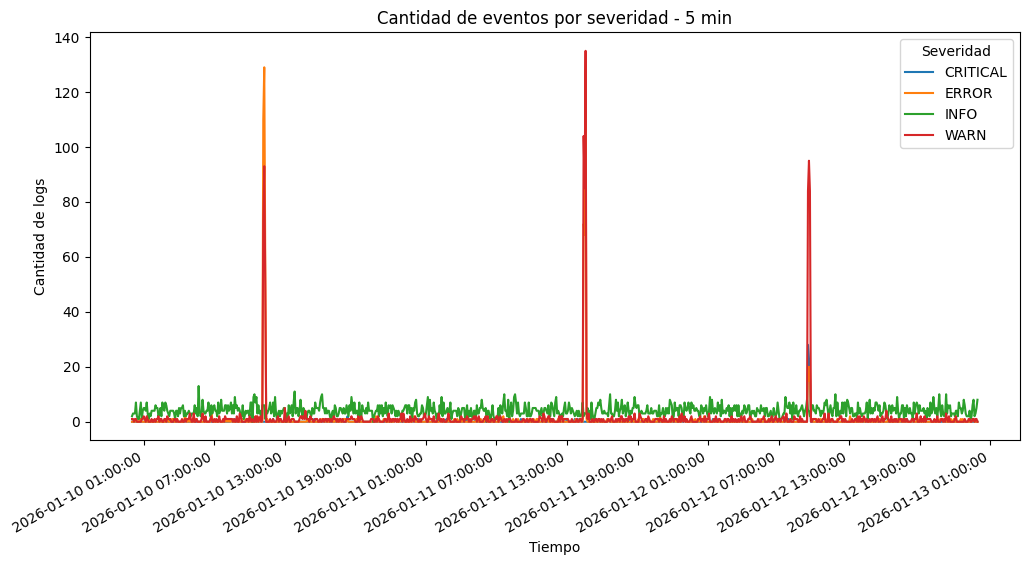

In [106]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Se agrupa a tiempo de 5 minutos por severidad, luego se cuenta
count_severidad = data_frame.groupby([pd.Grouper(key='timestamp_event', freq='5min'), 'severity']).size()

#Se crea una tabla para graficar
dato_grafico = count_severidad.unstack(fill_value=0)

# Grafico de lineas
ax = dato_grafico.plot(kind='line', figsize=(12, 6))

plt.title('Cantidad de eventos por severidad - 5 min')
plt.xlabel('Tiempo')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M:%S'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))          #Visualizacion de intervalos de tiempos(horas)
plt.ylabel('Cantidad de logs')
plt.legend(title='Severidad')
plt.show()

**Gráfico 2 - bad_rate en bins de 5 min**

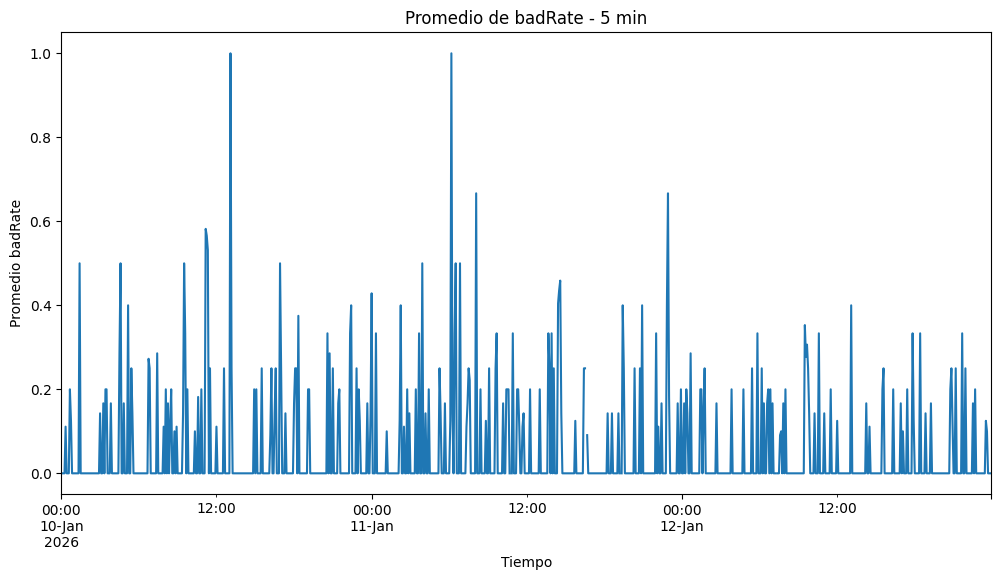

In [ ]:
ax = data_frame_resumen['badRate'].plot(kind='line', figsize=(12, 6))
plt.title('Promedio de badRate - 5 min')
plt.xlabel('Tiempo')
plt.ylabel('Promedio badRate')
plt.show()